In [ ]:
import pandas as pd
from src.data import DATA_DIR_INTERIM

from src.io import load_qrels_from_path, read_metadata
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate.measures_agreement import CohenKappa, AreaUnderReceiver, MeanAverageError
from topic_gen.evaluate.utils import QrelsTransformer

from topic_gen import logger
logger.setLevel("DEBUG")

### Binary Relevance Labels

In [ ]:
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
experiments = load_qrels_from_path(
    BASE_DIR, binarize_qrels=1, drop_relevance_values=999)

In [ ]:
baseline = load_from_irds("disks45/nocr/trec-robust-2004", binarize_qrels=1)
baseline.qrels = QrelsTransformer.drop_relevance(
    baseline.qrels, drop_values=999)

In [ ]:
meta_exp = MetaExperiment(
    experiments=experiments,
    baseline=baseline,
    measures=[CohenKappa(), AreaUnderReceiver(), MeanAverageError()],
    filter_qrels=True
)

In [ ]:
res = meta_exp.evaluate()

In [ ]:
metadata = read_metadata(BASE_DIR)

In [ ]:
df = pd.DataFrame(res)
# df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="value").reset_index()
df = df.merge(metadata, left_on="name", right_on="date")

## **Alignment:** How well align generated qrels based on generated topics with the original qrels?
 
- Judgments based on the original topics are always better but sometimes just a little!
- More context is allmost allways better
- Only not relevant documents works not well but in conjunction with relevant documents it actually does!
- For contrastive prompting, query variants can be substituded with more documents
- Query variants and relevant documents are the most important context information.
- Query variants with positive documents perfomrs the best followed by contrastive with variants 

In [ ]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "human",
    "topic-query",
    "topic-docs-pos",
    "topic-docs-neg",
    "topic-query-docs-pos",
    "topic-query-docs-neg",
    "topic-contrastive",
    "topic-query-contrastive"
]
df["topics_prompt"] = pd.Categorical(df["topics_prompt"], prompt_sorter)

df[(df["prompt"] == "-DNA-zero-shot") & \
    #   (df["model"] == model) &
   ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["name", "model", "topics_prompt", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,name,model,topics_prompt,topics_nqueries,topics_ndocspos,topics_ndocsneg,CohenKappa,MeanAverageError,AreaUnderReceiver
0,2025-11-27_06:56:22,qwen3-30B-no-think,human,NaN,NaN,NaN,0.758615,0.102730,0.896110
1,2025-11-27_07:35:52,qwen3-30B-no-think,topic-query,1.0,0.0,0.0,0.657440,0.160720,0.818513
2,2025-11-27_07:41:41,qwen3-30B-no-think,topic-query,3.0,0.0,0.0,0.695130,0.141008,0.837341
3,2025-11-27_07:47:26,qwen3-30B-no-think,topic-query,5.0,0.0,0.0,0.684565,0.146939,0.831711
4,2025-11-27_07:53:14,qwen3-30B-no-think,topic-query,7.0,0.0,0.0,0.686801,0.145826,0.833007
5,2025-11-27_07:59:06,qwen3-30B-no-think,topic-docs-pos,0.0,1.0,0.0,0.191155,0.480462,0.660771
6,2025-11-27_08:04:56,qwen3-30B-no-think,topic-docs-pos,0.0,2.0,0.0,0.246902,0.431579,0.671922
7,2025-11-27_08:10:50,qwen3-30B-no-think,topic-docs-pos,0.0,3.0,0.0,0.318498,0.375297,0.691679
8,2025-11-27_08:16:45,qwen3-30B-no-think,topic-docs-pos,0.0,4.0,0.0,0.391677,0.324499,0.716928
9,2025-11-27_08:22:42,qwen3-30B-no-think,topic-docs-pos,0.0,5.0,0.0,0.435979,0.290147,0.725855


## Plot 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame(res)
df = df.merge(metadata, left_on="name", right_on="date")
df = df[(df["prompt"] == "qrel_zeroshot_bing") & ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))]

In [ ]:
models = df["model"].unique()
colors = sns.color_palette("tab10", len(models))
model_colors = dict(zip(models, colors))

In [ ]:
g = sns.relplot(
    data=df[df["topics_prompt"].isin(['topic-query-docs-pos', 'topic-query-contrastive','topic-contrastive', "topic-docs-pos"])],
    x="topics_ndocspos",
    y="value",
    hue="model",
    style="topics_prompt",
    col="measure",
    kind="line",
    height=3,
    palette=model_colors,
    aspect=1.5,
    facet_kws={"sharey": False},
)

for ax in g.axes.flatten():
    ax.set_xbound(1,5)
    ax.set_xlabel("Context")
#     title = ax.get_title()
#     measure = title.split(" = ")[1].replace(" | field", "")
#     if measure in y_mins:
#         ax.set_ylim(bottom=y_mins[measure])


plt.show()

In [17]:
def plot(subset_prompt_list, df, x="topics_nqueries"):
    df = df.copy()
    baseline = df[df["topics_prompt"] == "human"]
    df = df[df["topics_prompt"].isin(subset_prompt_list)]
    unique_prompts = df["topics_prompt"].unique()
    palette = sns.color_palette("tab10", len(unique_prompts))
    color_map = dict(zip(unique_prompts, palette))

    for measure_name, g in df.groupby("measure"):
        fig, ax = plt.subplots(figsize=(6, 4))
        g = g.copy()
        # g['ci_lower'] = g['value'] - g['ci']
        # g['ci_upper'] = g['value'] + g['ci']

        sns.lineplot(
            data=g,
            x=x,
            y="value",
            hue="topics_prompt",
            palette=color_map,
            ax=ax,
            errorbar=None
        )
        # for prompt_name, sub_g in g.groupby("topics_prompt"):
        #     sub_g = sub_g.sort_values(x)
        #     color = color_map[prompt_name]

        #     ax.fill_between(
        #         sub_g[x],
        #         sub_g['ci_lower'],
        #         sub_g['ci_upper'],
        #         color=color,
        #         alpha=0.15
        #     )

        ax.axhline(y=float(baseline[baseline["measure"] == measure_name]["value"].iloc[0]), linestyle='--',
                   label=f"Original Topic", color='gray')
        ax.set_title(f"Measure: {measure_name}")

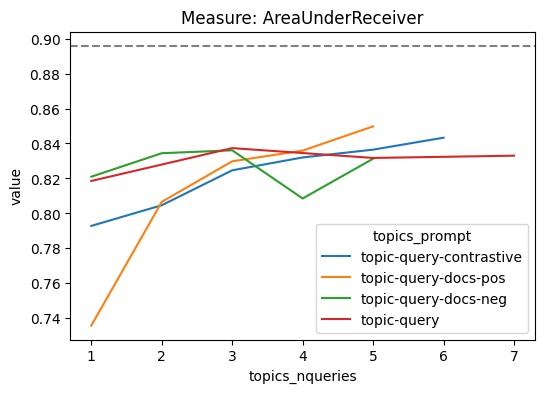

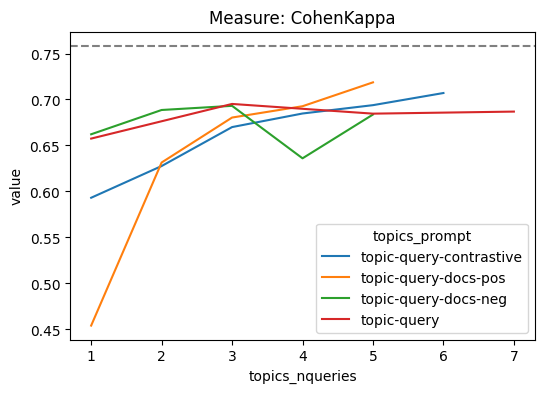

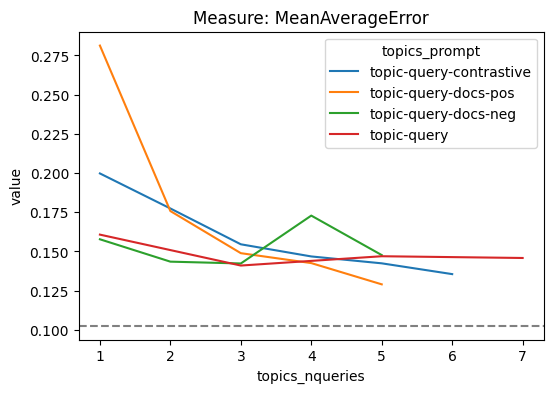

In [18]:
plot(['topic-query-docs-pos', 'topic-query-docs-neg',
     'topic-query', 'topic-query-contrastive'], df)

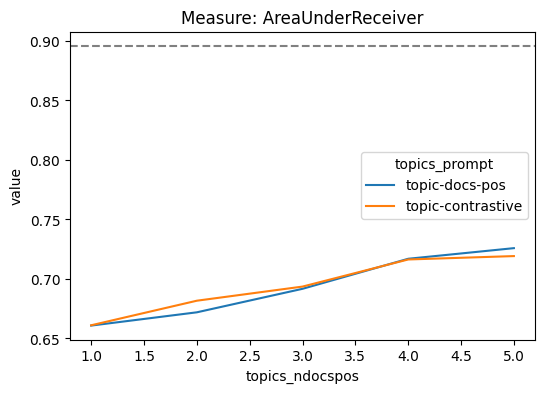

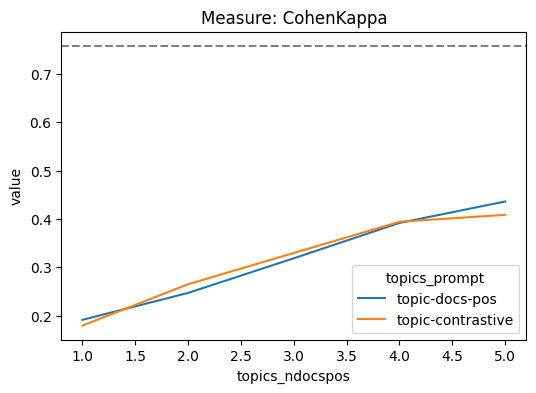

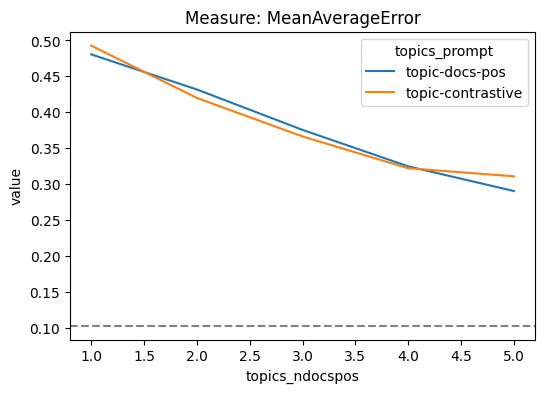

In [19]:
plot(['topic-docs-pos', 'topic-contrastive'], df, x="topics_ndocspos")

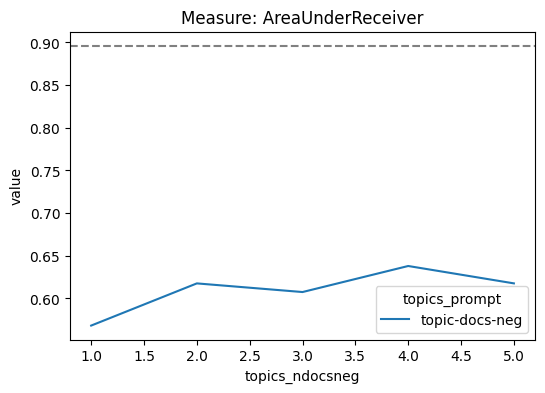

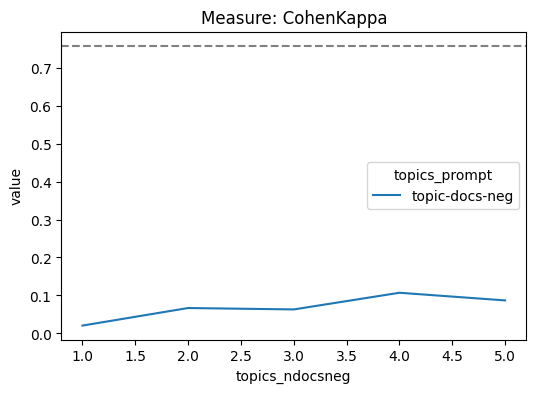

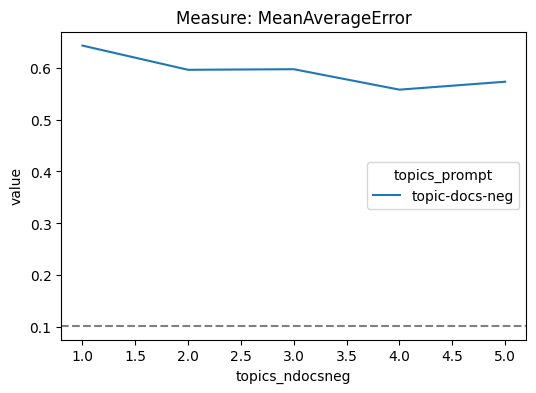

In [20]:
plot(['topic-docs-neg'], df, x="topics_ndocsneg")